# Clustering Basics — Beginner Friendly Guide

This notebook introduces **unsupervised learning using clustering algorithms**.

Unlike supervised learning, clustering **does not use labels**.  
Instead, the goal is to discover **natural groupings within the data**.

In this notebook we will:

1. Generate a synthetic dataset
2. Visualize the dataset
3. Apply **K-Means Clustering**
4. Use the **Elbow Method** to choose the best number of clusters
5. Apply **Hierarchical (Agglomerative) Clustering**
6. Apply **DBSCAN Clustering**
7. Compare clustering results

Libraries used:
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit‑learn

## Import Libraries

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

## Generate Synthetic Dataset

We will generate a simple dataset with **2 features** and **400 data points**.

`make_blobs()` creates clusters automatically so we can test clustering algorithms.

In [14]:
X, y = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

X.shape

(400, 2)

## Visualize the Dataset

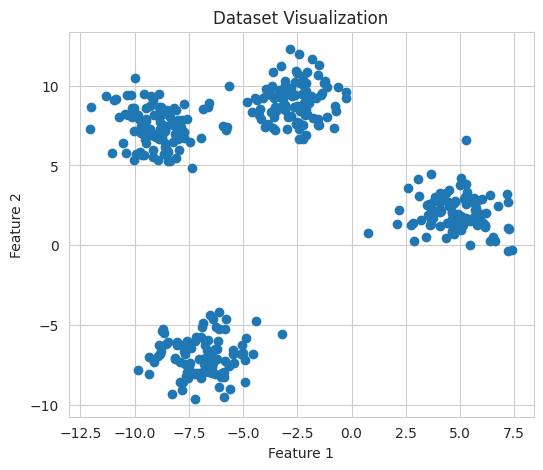

In [15]:
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1])

plt.title("Dataset Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# K-Means Clustering

K-Means is one of the **most commonly used clustering algorithms**.

Steps:

1. Choose number of clusters (K)
2. Randomly initialize cluster centroids
3. Assign each point to nearest centroid
4. Update centroid positions
5. Repeat until convergence

## Train KMeans Model

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_

/opt/envs/ds/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


## Visualize KMeans Clusters

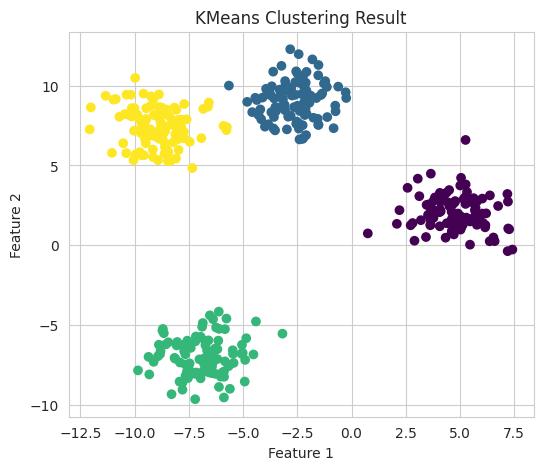

In [17]:
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis")

plt.title("KMeans Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Elbow Method

The Elbow Method helps determine the **optimal number of clusters**.

We train KMeans with different values of K and measure:

**Inertia (Within Cluster Sum of Squares)**

The point where inertia stops decreasing sharply is the **optimal K**.

In [18]:
inertia = []

k_values = range(1,10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

/opt/envs/ds/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/envs/ds/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/envs/ds/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/opt/envs/ds/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_

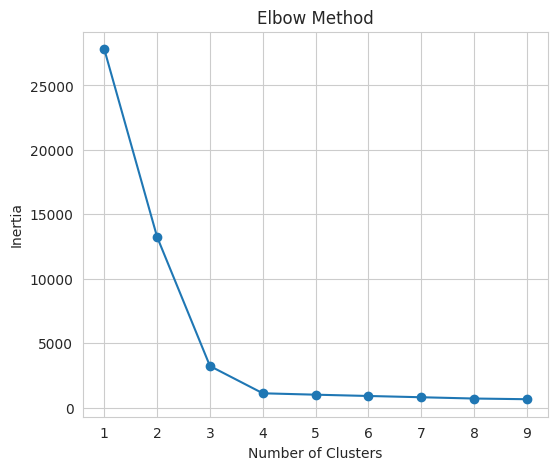

In [19]:
plt.figure(figsize=(6,5))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# Hierarchical Clustering

Hierarchical clustering builds a **tree-like cluster structure**.

Agglomerative clustering works by:

1. Treating each data point as its own cluster
2. Iteratively merging closest clusters

In [20]:
agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(X)

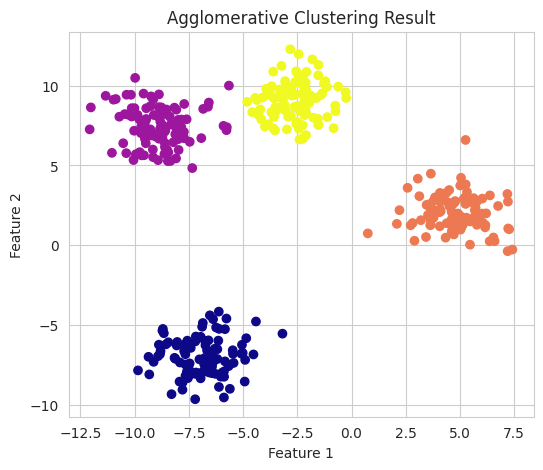

In [21]:
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=agg_labels, cmap="plasma")

plt.title("Agglomerative Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# DBSCAN Clustering

DBSCAN groups points based on **density**.

Advantages:

- Can detect **noise points**
- Works well with **arbitrary shaped clusters**

In [22]:
dbscan = DBSCAN(eps=0.7, min_samples=5)

db_labels = dbscan.fit_predict(X)

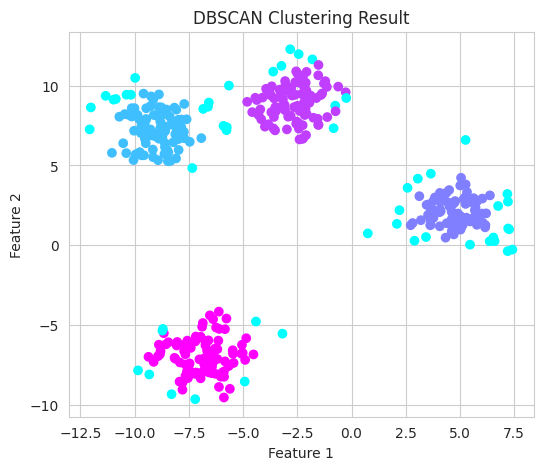

In [23]:
plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=db_labels, cmap="cool")

plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Groupby aggregation with clustering

In [2]:
import statsmodels.api as sm
import pandas as pd

# Load the mtcars dataset from R
mtcars_r = sm.datasets.get_rdataset('mtcars')

# Access the data as a pandas DataFrame
mtcars_df = mtcars_r.data

# Print the first few rows to verify
mtcars_df.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(mtcars_df)

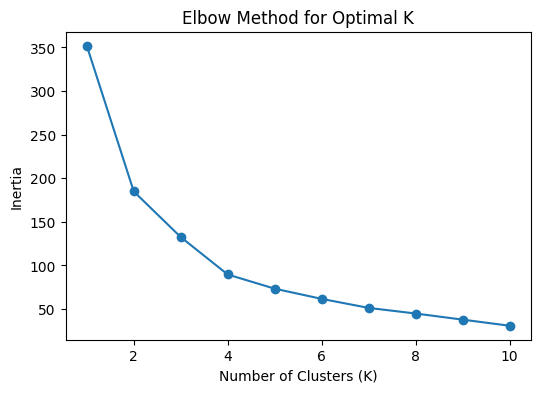

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

mtcars_df["cluster"] = clusters

In [6]:
mtcars_df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cluster
rownames,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,2
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,2
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,3
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,0


In [11]:
pd.set_option('display.max_columns', 300)


In [12]:
cluster_summary = mtcars_df.groupby("cluster").agg(["mean","sum","median","count"])

cluster_summary

mpg                           cyl                         disp  \
              mean    sum median count      mean sum median count        mean   
cluster                                                                         
0        15.050000  180.6  15.20    12  8.000000  96    8.0    12  357.616667   
1        20.742857  145.2  21.40     7  5.142857  36    6.0     7  175.114286   
2        18.500000   92.5  19.70     5  6.800000  34    6.0     5  223.400000   
3        28.075000  224.6  28.85     8  4.000000  32    4.0     8   93.612500   

                                       hp                         drat         \
            sum  median count        mean   sum median count      mean    sum   
cluster                                                                         
0        4291.4  355.00    12  194.166667  2330  180.0    12  3.120833  37.45   
1        1225.8  167.60     7  102.142857   715  105.0     7  3.570000  24.99   
2        1117.0  160.00     5  198.800000   994  175.0     5  3.836000  19.18   
3         748.9   87.05     8   81.875000   655   78.5     8  4.183750  33.47   

                            wt                             qsec          \
        median count      mean     sum  median count       mean     sum   
cluster                                                                   
0        3.075    12  4.104083  49.249  3.8100    12  17.142500  205.71   
1        3.700     7  3.194286  22.360  3.2150     7  19.967143  139.77   
2        3.900     5  3.001000  15.005  2.8750     5  15.616000   78.08   
3        4.095     8  2.042250  16.338  2.0375     8  18.450000  147.60   

                          vs                    am                       gear  \
         median count   mean sum median count mean sum median count      mean   
cluster                                                                         
0        17.350    12  0.000   0    0.0    12  0.0   0    0.0    12  3.000000   
1        20.000     7  1.000   7    1.0     7  0.0   0    0.0     7  3.571429   
2        15.500     5  0.000   0    0.0     5  1.0   5    1.0     5  4.600000   
3        18.605     8  0.875   7    1.0     8  1.0   8    1.0     8  4.250000   

                              carb                   
        sum median count      mean sum median count  
cluster                                              
0        36    3.0    12  3.083333  37    3.0    12  
1        25    4.0     7  2.142857  15    2.0     7  
2        23    5.0     5  5.200000  26    4.0     5  
3        34    4.0     8  1.500000  12    1.5     8

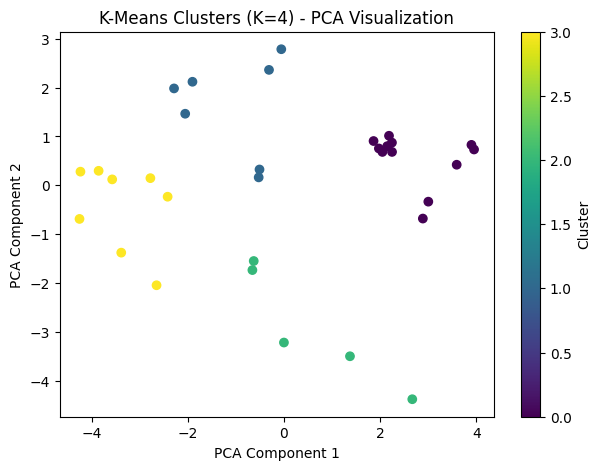

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=mtcars_df["cluster"], cmap="viridis")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (K=4) - PCA Visualization")

plt.colorbar(label="Cluster")
plt.show()

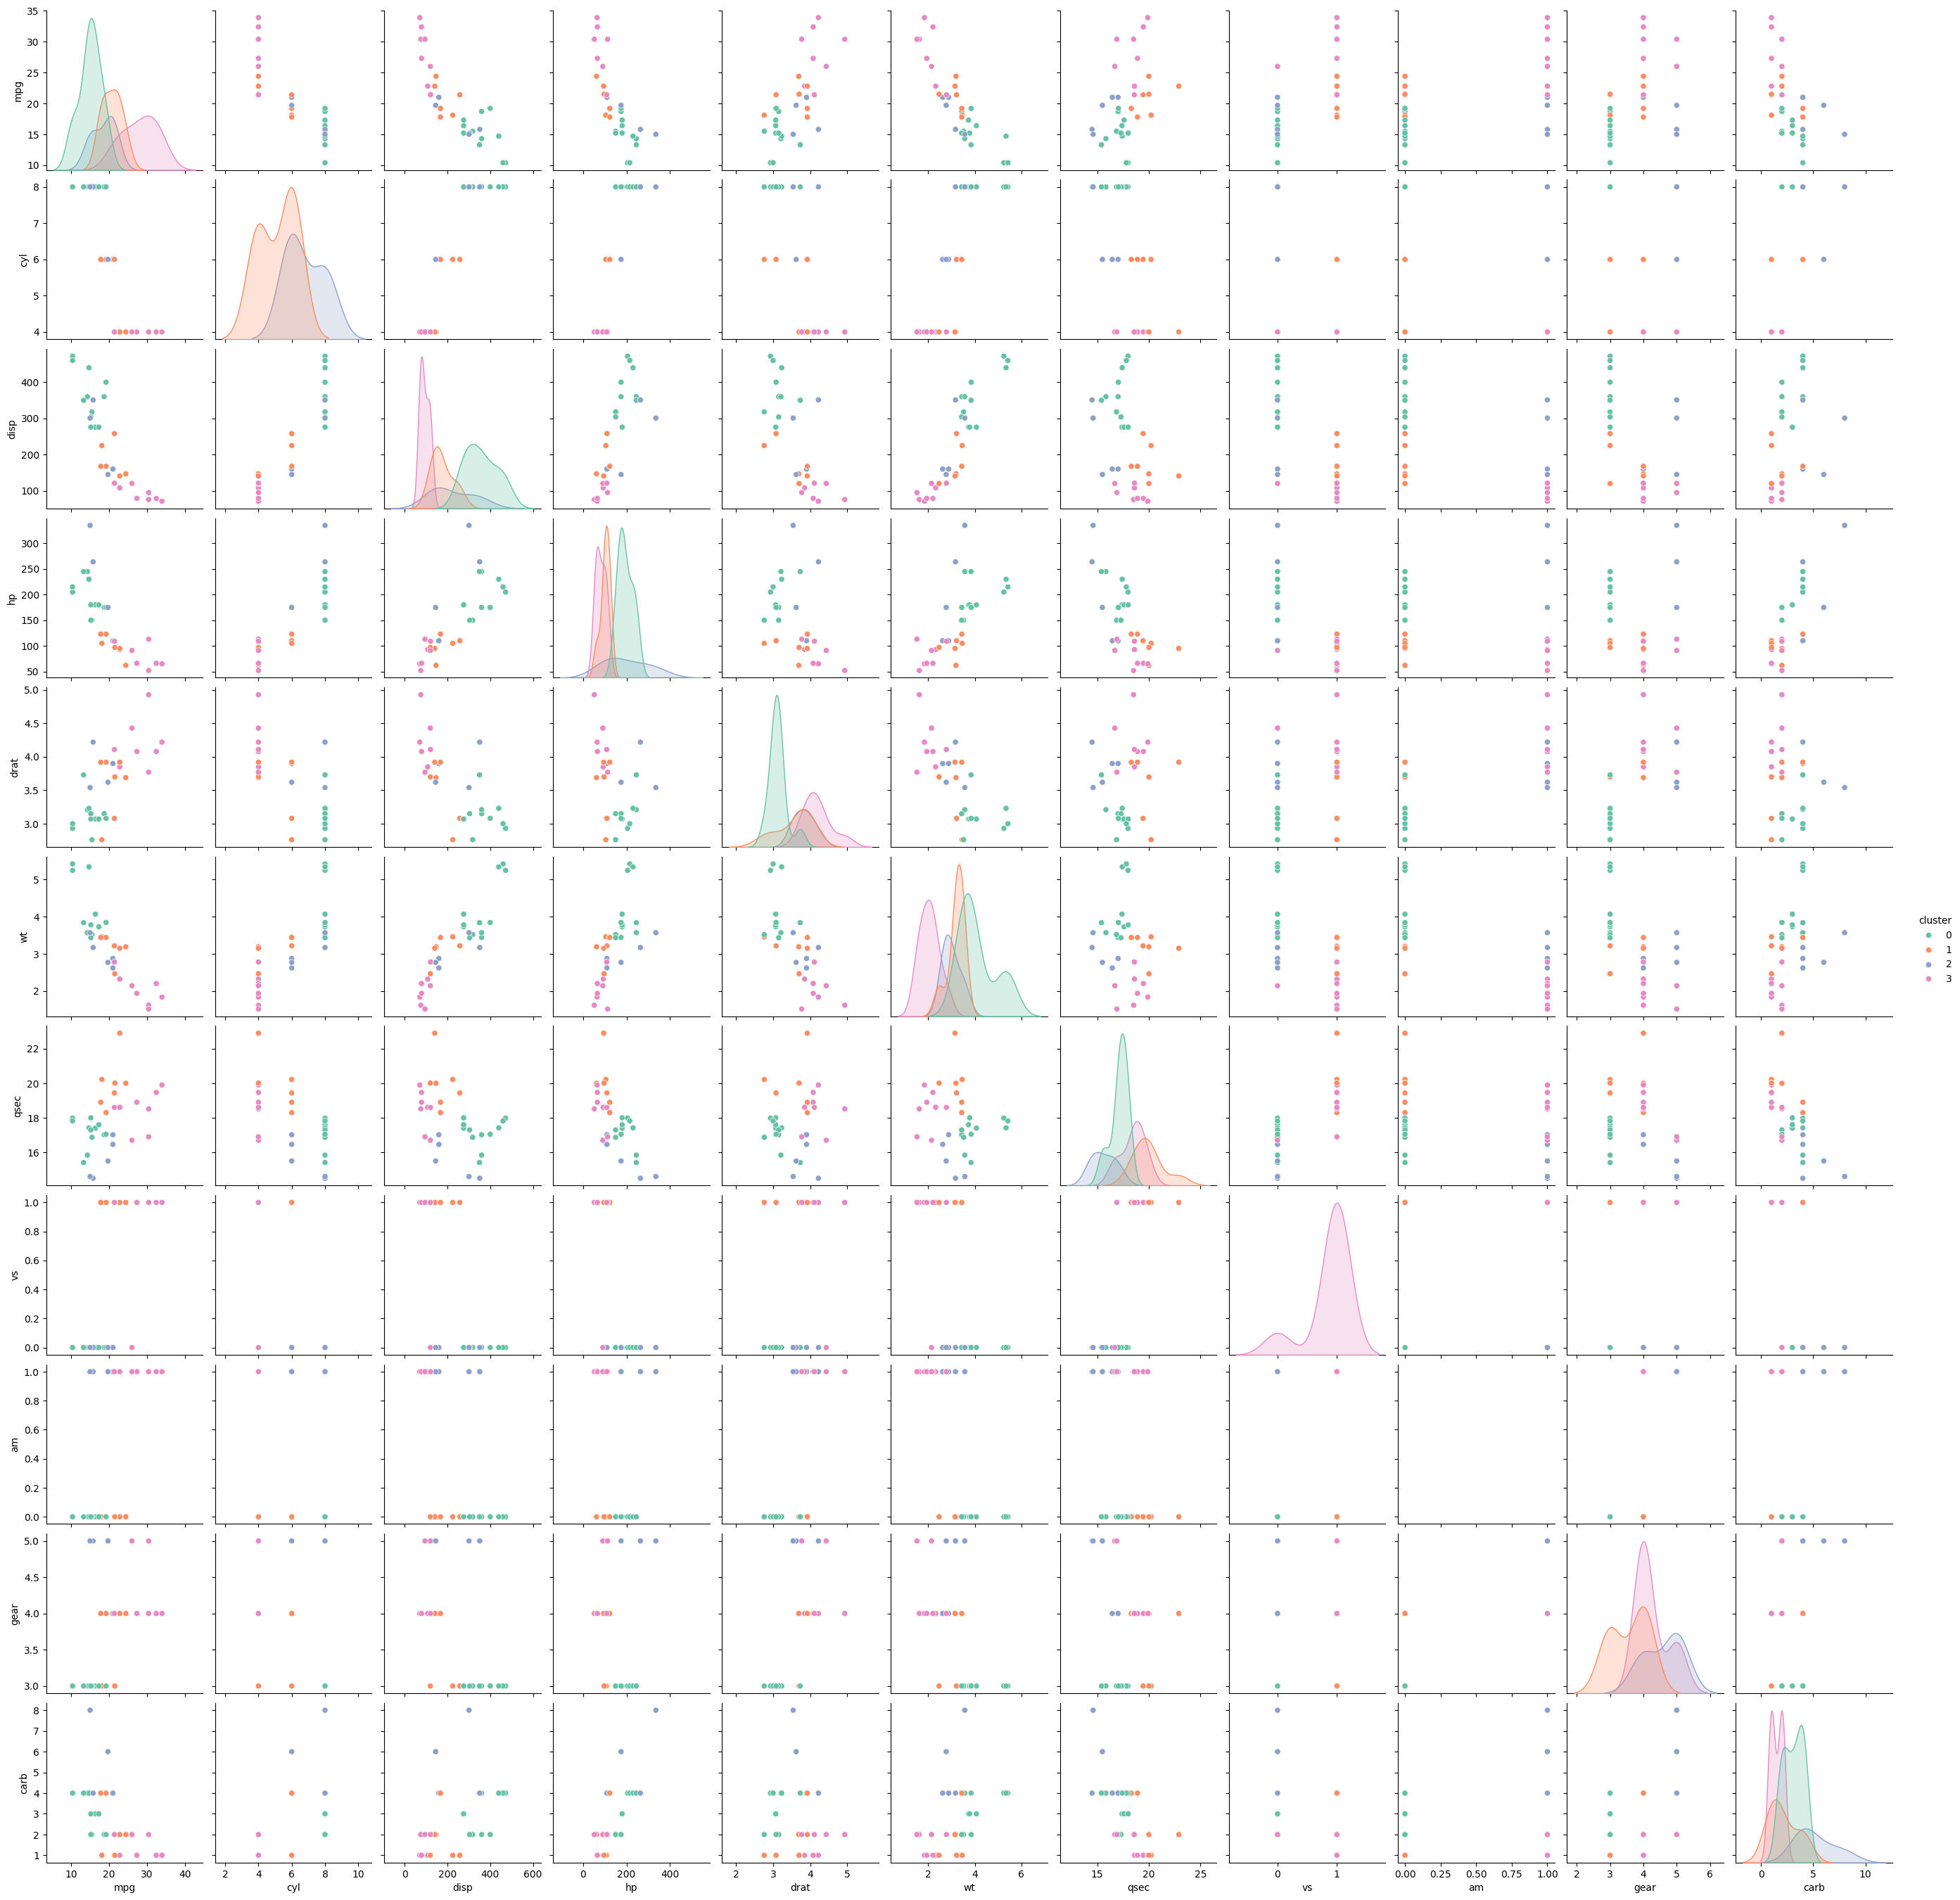

In [15]:
import seaborn as sns

sns.pairplot(
    mtcars_df,
    hue="cluster",
    palette="Set2",
    diag_kind="kde"
)

plt.show()